In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT/malignant/malignant (102)_mask.png
/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT/malignant/malignant (100).png
/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT/malignant/malignant (104)_mask.png
/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT/malignant/malignant (101)_mask.png
/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT/malignant/malignant (103)_mask.png
/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT/malignant/malignant (1)_mask.png
/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT/malignant/malignant (1).png
/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT/malignant/malignant (100)_mask.png
/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT/malignant/malignant (103).png
/content/drive/MyDrive/Breast-Cancer-Classifica

In [ ]:
!ls "/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT"

benign	malignant  normal


In [ ]:
base_path = "/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT"
categories = ["benign","malignant", "normal"]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/Breast-Cancer-Classification/Dataset_BUSI_with_GT"
categories = ["benign", "malignant", "normal"]
data = []

for category in categories:
    category_path = os.path.join(base_path, category)
    files = sorted(os.listdir(category_path))

    for file in files:
        if "_mask" in file:
            continue

        img_path = os.path.join(category_path, file)
        mask_path = os.path.join(category_path, file.replace(".png", "_mask.png"))

        data.append([img_path, mask_path, category])

df = pd.DataFrame(data, columns=["Image_Path", "Mask_Path", "Label"])

In [ ]:
df.head()

,Image_Path,Mask_Path,Label
0,/content/drive/MyDrive/Breast-Cancer-Classific...,/content/drive/MyDrive/Breast-Cancer-Classific...,benign
1,/content/drive/MyDrive/Breast-Cancer-Classific...,/content/drive/MyDrive/Breast-Cancer-Classific...,benign
2,/content/drive/MyDrive/Breast-Cancer-Classific...,/content/drive/MyDrive/Breast-Cancer-Classific...,benign
3,/content/drive/MyDrive/Breast-Cancer-Classific...,/content/drive/MyDrive/Breast-Cancer-Classific...,benign
4,/content/drive/MyDrive/Breast-Cancer-Classific...,/content/drive/MyDrive/Breast-Cancer-Classific...,benign


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Image_Path  780 non-null    object
 1   Mask_Path   780 non-null    object
 2   Label       780 non-null    object
dtypes: object(3)
memory usage: 18.4+ KB


In [ ]:
df.tail()

,Image_Path,Mask_Path,Label
775,/content/drive/MyDrive/Breast-Cancer-Classific...,/content/drive/MyDrive/Breast-Cancer-Classific...,normal
776,/content/drive/MyDrive/Breast-Cancer-Classific...,/content/drive/MyDrive/Breast-Cancer-Classific...,normal
777,/content/drive/MyDrive/Breast-Cancer-Classific...,/content/drive/MyDrive/Breast-Cancer-Classific...,normal
778,/content/drive/MyDrive/Breast-Cancer-Classific...,/content/drive/MyDrive/Breast-Cancer-Classific...,normal
779,/content/drive/MyDrive/Breast-Cancer-Classific...,/content/drive/MyDrive/Breast-Cancer-Classific...,normal


In [ ]:
df.shape

(780, 3)

In [ ]:
df.columns

Index(['Image_Path', 'Mask_Path', 'Label'], dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Image_Path  780 non-null    object
 1   Mask_Path   780 non-null    object
 2   Label       780 non-null    object
dtypes: object(3)
memory usage: 18.4+ KB


In [ ]:
df['Label'].unique()

array(['benign', 'malignant', 'normal'], dtype=object)

In [ ]:
df['Label'].value_counts()

,count
Label,
benign,437
malignant,210
normal,133


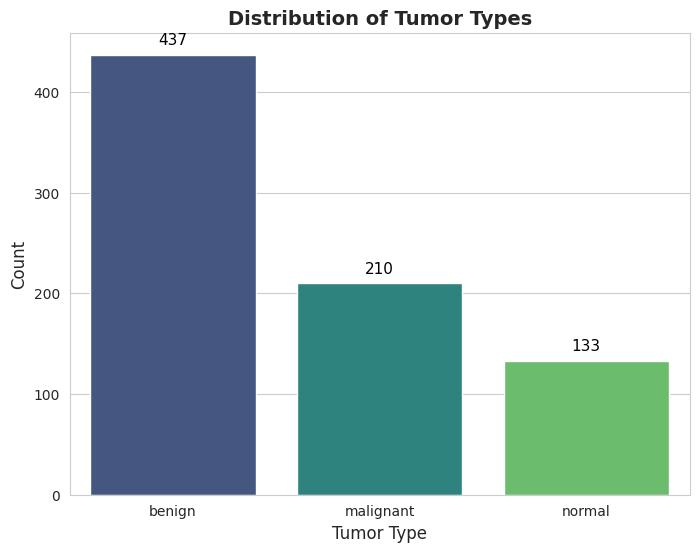

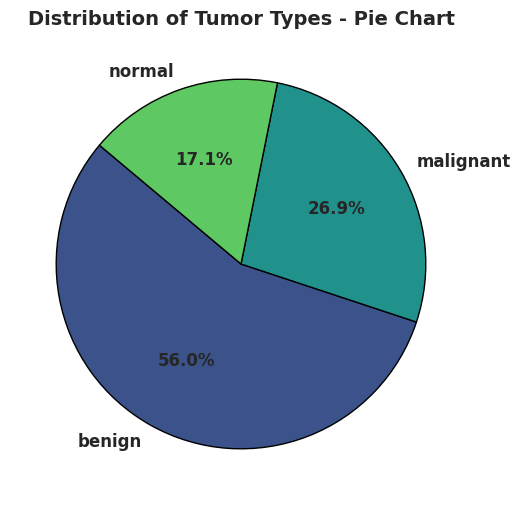

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df, x="Label", palette="viridis", ax=ax)

ax.set_title("Distribution of Tumor Types", fontsize=14, fontweight='bold')
ax.set_xlabel("Tumor Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.show()

label_counts = df["Label"].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("viridis", len(label_counts))

ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
       startangle=140, colors=colors, textprops={'fontsize': 12, 'weight': 'bold'},
       wedgeprops={'edgecolor': 'black', 'linewidth': 1})

ax.set_title("Distribution of Tumor Types - Pie Chart", fontsize=14, fontweight='bold')

plt.show()

# Bar Plot with Percentage


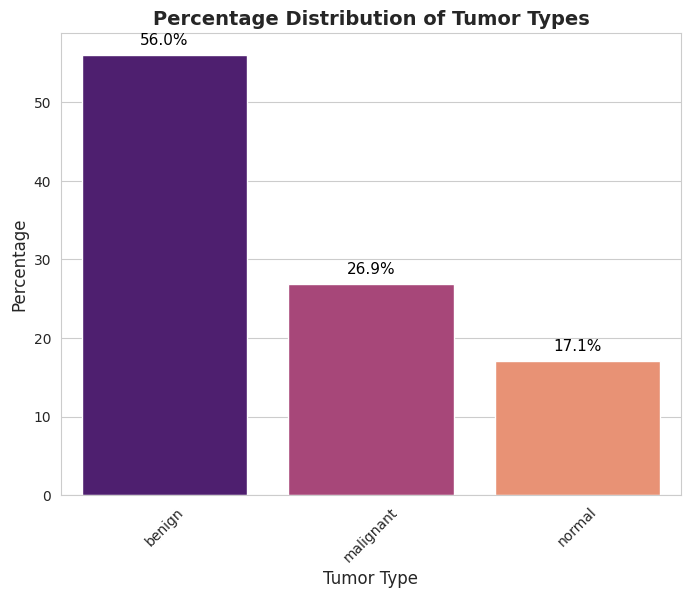

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
label_counts = df["Label"].value_counts(normalize=True) * 100  # Convert to percentage
sns.barplot(x=label_counts.index, y=label_counts.values, palette="magma", ax=ax)

ax.set_title("Percentage Distribution of Tumor Types", fontsize=14, fontweight='bold')
ax.set_xlabel("Tumor Type", fontsize=12)
ax.set_ylabel("Percentage", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.xticks(rotation=45)
plt.show()


In [ ]:
print(df.columns)

Index(['Image_Path', 'Mask_Path', 'Label'], dtype='object')


In [ ]:
print(df.info)

<bound method DataFrame.info of                                             Image_Path  \
0    /content/drive/MyDrive/Breast-Cancer-Classific...   
1    /content/drive/MyDrive/Breast-Cancer-Classific...   
2    /content/drive/MyDrive/Breast-Cancer-Classific...   
3    /content/drive/MyDrive/Breast-Cancer-Classific...   
4    /content/drive/MyDrive/Breast-Cancer-Classific...   
..                                                 ...   
775  /content/drive/MyDrive/Breast-Cancer-Classific...   
776  /content/drive/MyDrive/Breast-Cancer-Classific...   
777  /content/drive/MyDrive/Breast-Cancer-Classific...   
778  /content/drive/MyDrive/Breast-Cancer-Classific...   
779  /content/drive/MyDrive/Breast-Cancer-Classific...   

                                             Mask_Path   Label  
0    /content/drive/MyDrive/Breast-Cancer-Classific...  benign  
1    /content/drive/MyDrive/Breast-Cancer-Classific...  benign  
2    /content/drive/MyDrive/Breast-Cancer-Classific...  benign  
3    /conte

In [ ]:
print(df.head())

                                          Image_Path  \
0  /content/drive/MyDrive/Breast-Cancer-Classific...   
1  /content/drive/MyDrive/Breast-Cancer-Classific...   
2  /content/drive/MyDrive/Breast-Cancer-Classific...   
3  /content/drive/MyDrive/Breast-Cancer-Classific...   
4  /content/drive/MyDrive/Breast-Cancer-Classific...   

                                           Mask_Path   Label  
0  /content/drive/MyDrive/Breast-Cancer-Classific...  benign  
1  /content/drive/MyDrive/Breast-Cancer-Classific...  benign  
2  /content/drive/MyDrive/Breast-Cancer-Classific...  benign  
3  /content/drive/MyDrive/Breast-Cancer-Classific...  benign  
4  /content/drive/MyDrive/Breast-Cancer-Classific...  benign  


# Box Plot (Tumor Type vs. Numeric Feature)


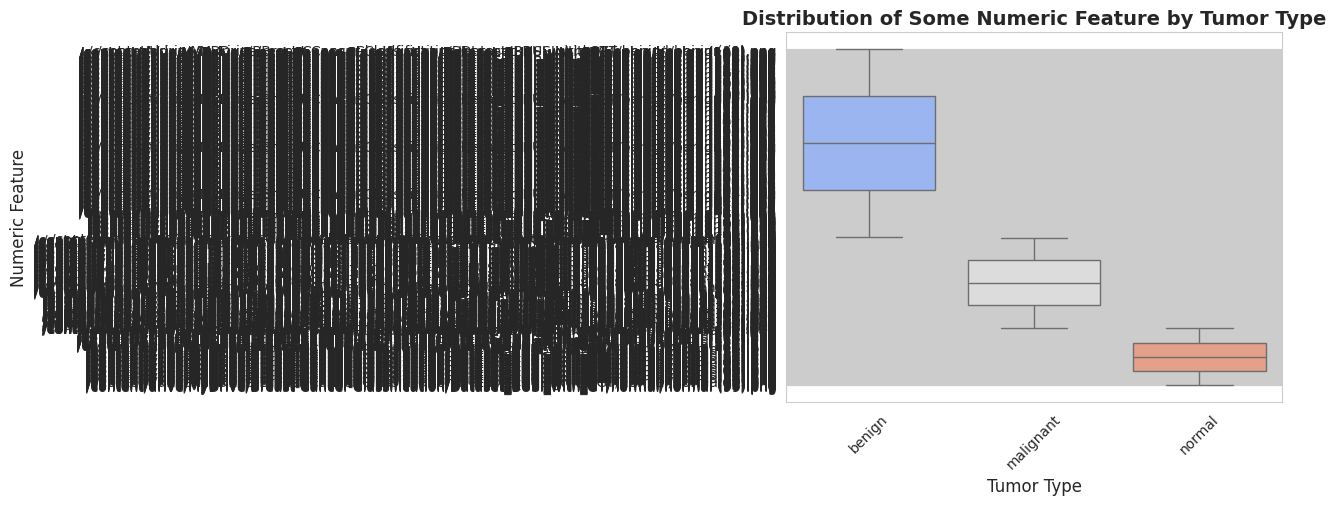

In [ ]:
sns.boxplot(data=df, x="Label", y="Image_Path", palette="coolwarm")
plt.title("Distribution of Some Numeric Feature by Tumor Type", fontsize=14, fontweight='bold')
plt.xlabel("Tumor Type", fontsize=12)
plt.ylabel("Numeric Feature", fontsize=12)
plt.xticks(rotation=45)
plt.show()


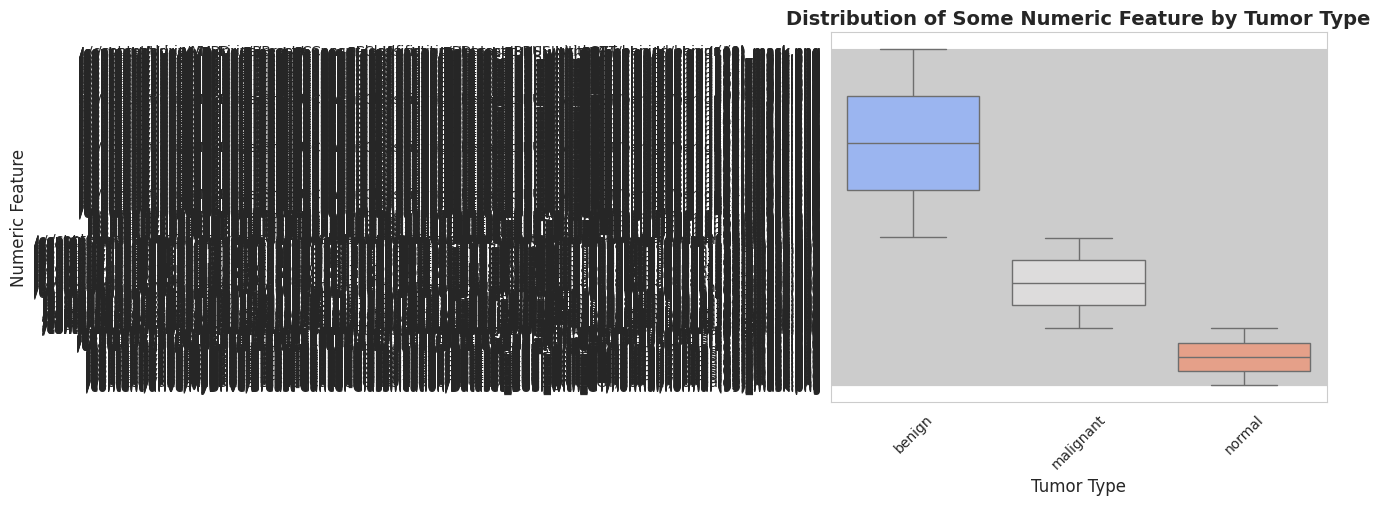

In [ ]:
sns.boxplot(data=df, x="Label", y="Mask_Path", palette="coolwarm")
plt.title("Distribution of Some Numeric Feature by Tumor Type", fontsize=14, fontweight='bold')
plt.xlabel("Tumor Type", fontsize=12)
plt.ylabel("Numeric Feature", fontsize=12)
plt.xticks(rotation=45)
plt.show()


#Violin Plot


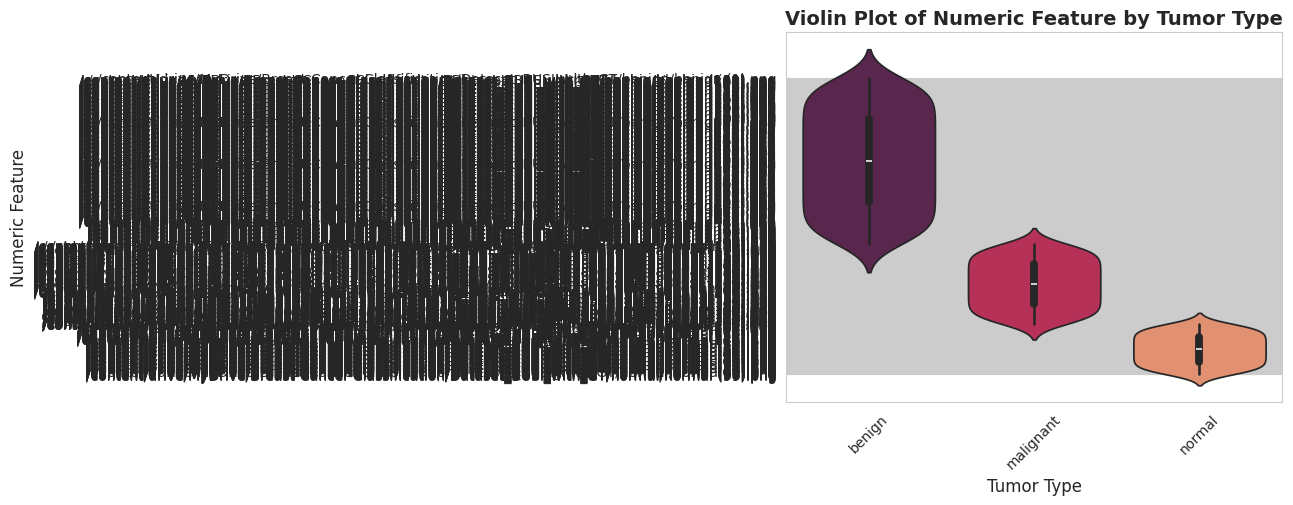

In [ ]:
sns.violinplot(data=df, x="Label", y="Image_Path", palette="rocket")
plt.title("Violin Plot of Numeric Feature by Tumor Type", fontsize=14, fontweight='bold')
plt.xlabel("Tumor Type", fontsize=12)
plt.ylabel("Numeric Feature", fontsize=12)
plt.xticks(rotation=45)
plt.show()


#Swarm Plot (Categorical vs. Numeric)


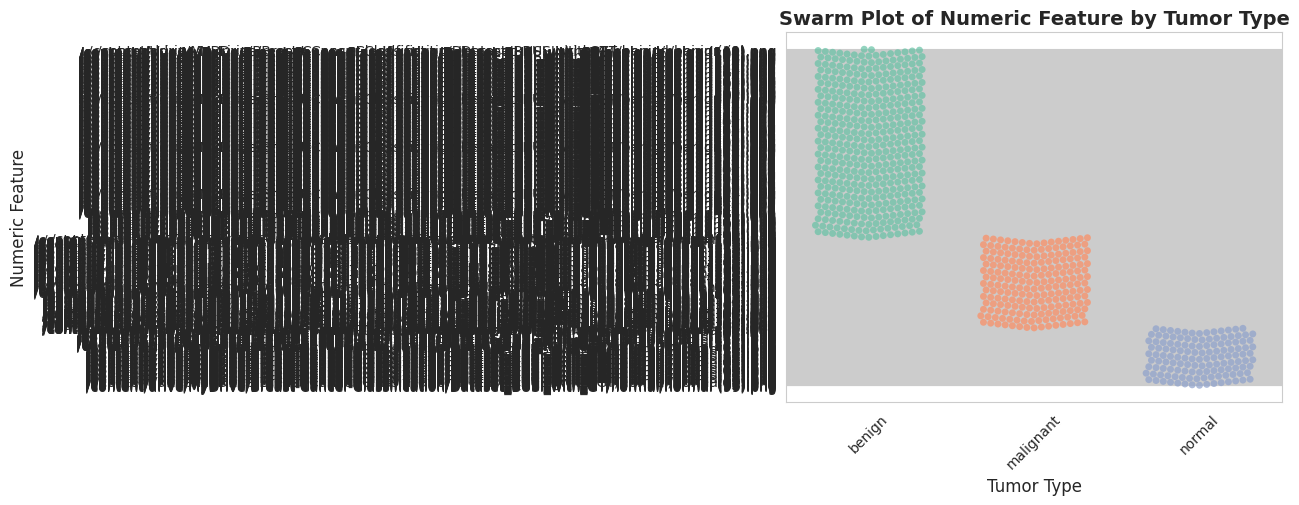

In [ ]:
sns.swarmplot(data=df, x="Label", y="Image_Path", palette="Set2", alpha=0.7)
plt.title("Swarm Plot of Numeric Feature by Tumor Type", fontsize=14, fontweight='bold')
plt.xlabel("Tumor Type", fontsize=12)
plt.ylabel("Numeric Feature", fontsize=12)
plt.xticks(rotation=45)
plt.show()


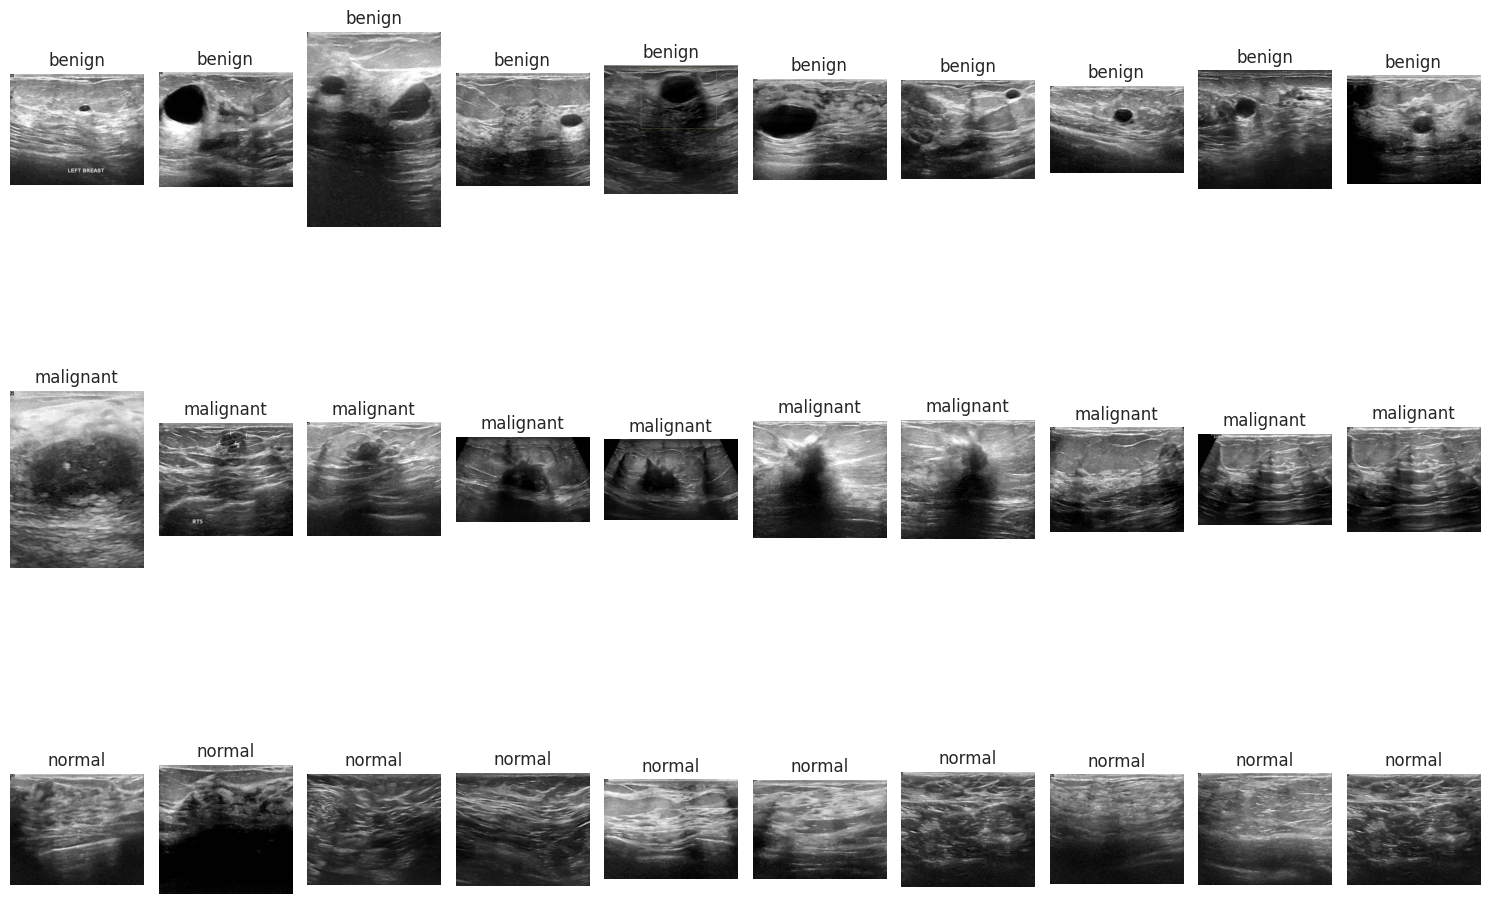

In [ ]:
import cv2
import matplotlib.pyplot as plt


num_images = 10
plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df[df["Label"] == category]["Image_Path"].iloc[:num_images]

    for j, img_path in enumerate(category_images):
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(category)

plt.tight_layout()
plt.show()

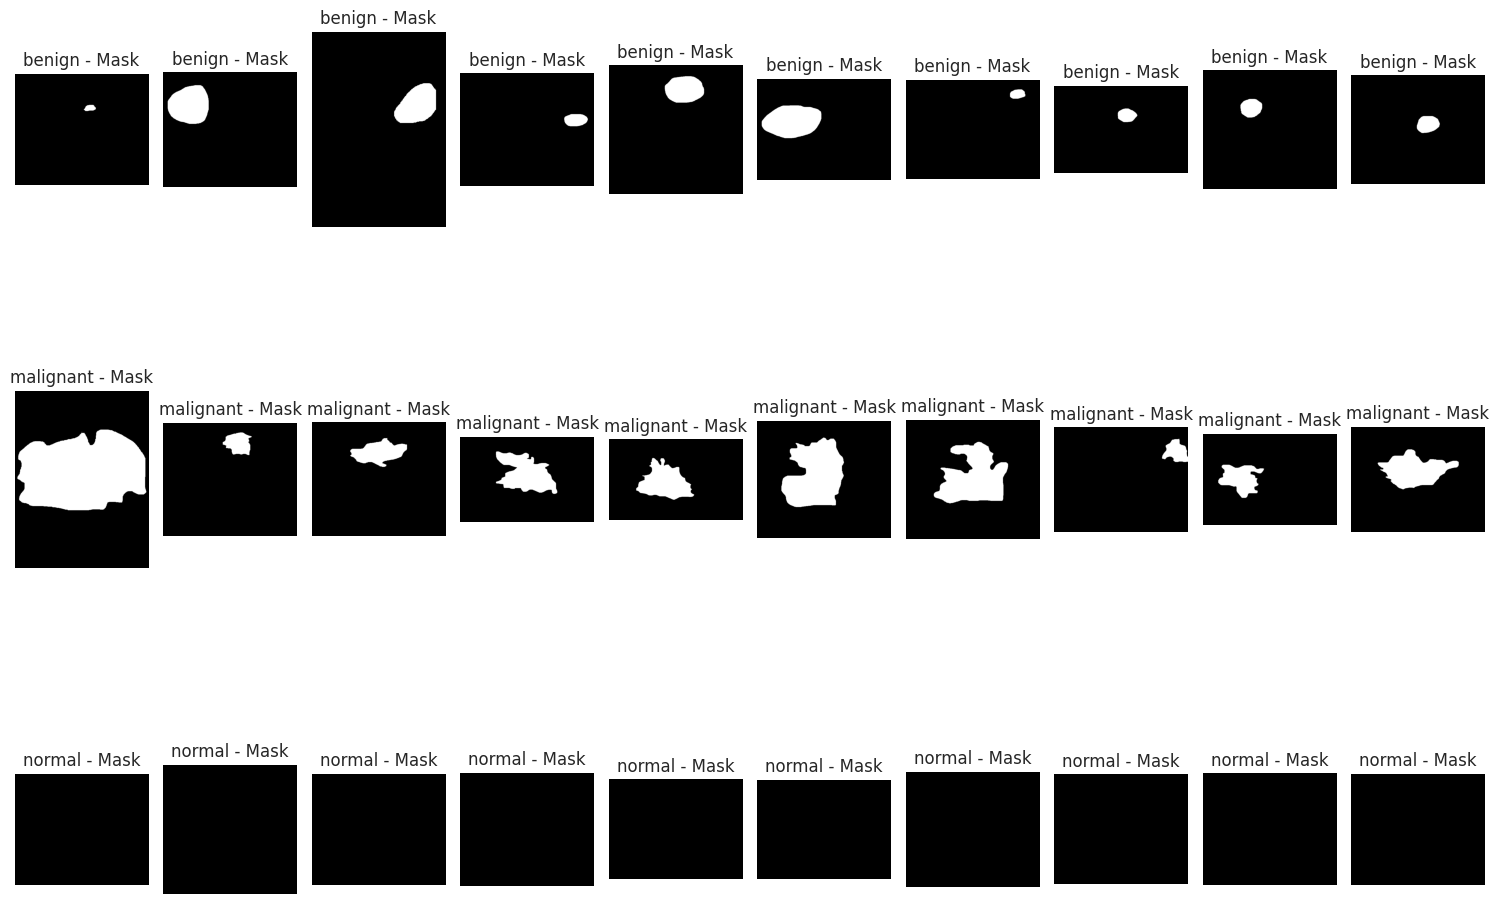

In [ ]:
num_images = 10
plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_masks = df[df["Label"] == category]["Mask_Path"].iloc[:num_images]

    for j, mask_path in enumerate(category_masks):
        mask = cv2.cvtColor(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2RGB)

        plt.subplot(len(categories), num_images, i * num_images + j + 1)
        plt.imshow(mask)
        plt.axis("off")
        plt.title(f"{category} - Mask")

plt.tight_layout()
plt.show()

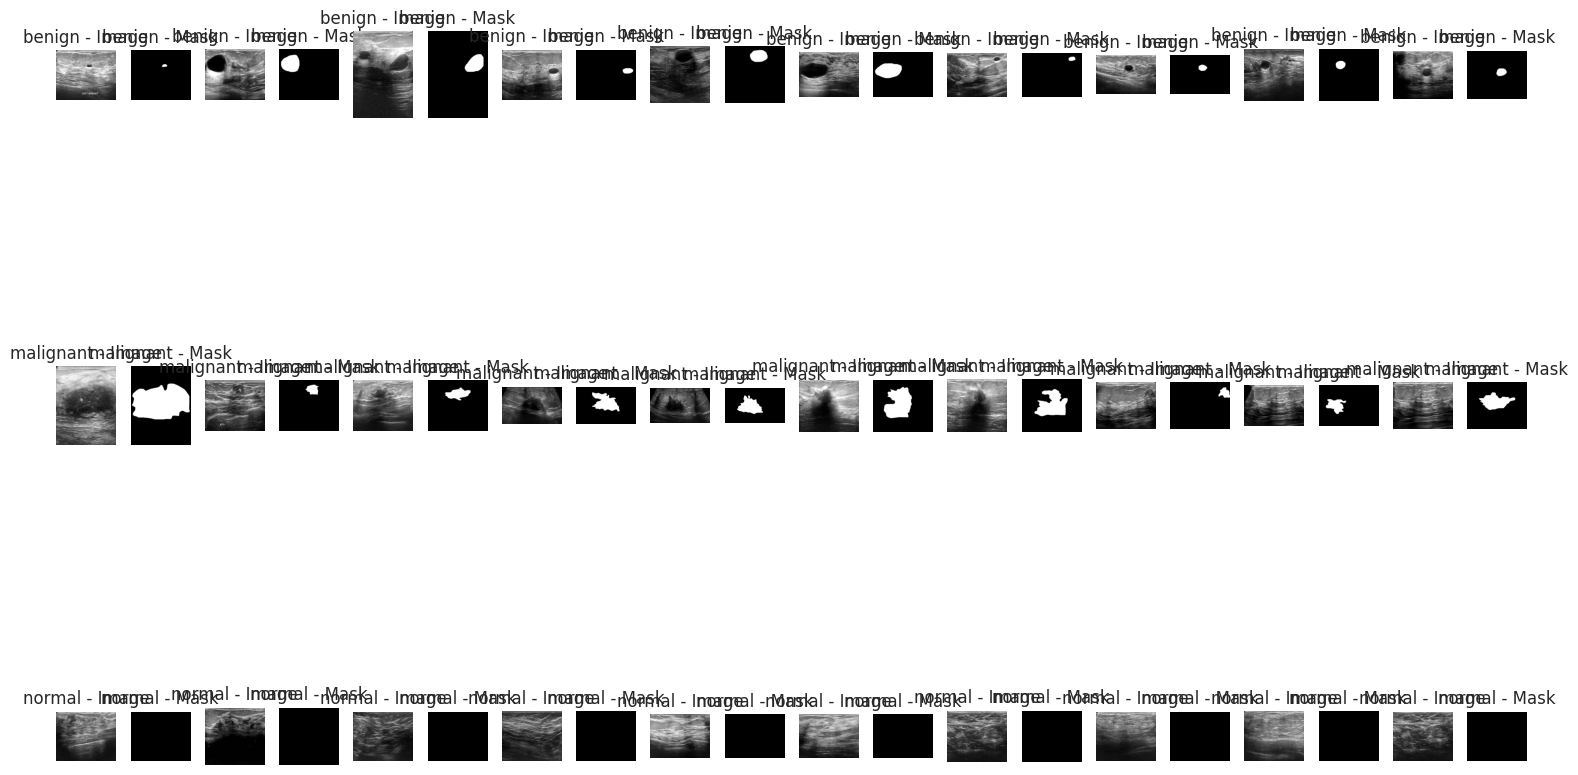

In [ ]:
num_images = 10
plt.figure(figsize=(15, 12))

for i, category in enumerate(categories):
    category_images = df[df["Label"] == category]["Image_Path"].iloc[:num_images]
    category_masks = df[df["Label"] == category]["Mask_Path"].iloc[:num_images]

    for j, (img_path, mask_path) in enumerate(zip(category_images, category_masks)):
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.cvtColor(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2RGB)

        plt.subplot(len(categories), num_images * 2, i * num_images * 2 + j * 2 + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{category} - Image")

        plt.subplot(len(categories), num_images * 2, i * num_images * 2 + j * 2 + 2)
        plt.imshow(mask)
        plt.axis("off")
        plt.title(f"{category} - Mask")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['category_encoded'] = label_encoder.fit_transform(df['Label'])

In [ ]:
df = df[['Image_Path', 'category_encoded']]

In [ ]:
pip install smote_variants

In [ ]:
!pip install --upgrade smote_variants

Use SMOTE inplace of Random Oversampler (ESMOTE etc)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

In [ ]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(df[['Image_Path']], df['category_encoded'])

In [ ]:
df_resampled = pd.DataFrame(X_resampled, columns=['Image_Path'])
df_resampled['category_encoded'] = y_resampled

In [ ]:
y_resampled

,category_encoded
0,0
1,0
2,0
3,0
4,0
...,...
1306,2
1307,2
1308,2
1309,2


In [ ]:
print("\nClass distribution after oversampling:")
print(df_resampled['category_encoded'].value_counts())


Class distribution after oversampling:
category_encoded
0    437
1    437
2    437
Name: count, dtype: int64


In [ ]:
df_resampled

,Image_Path,category_encoded
0,/content/drive/MyDrive/Breast-Cancer-Classific...,0
1,/content/drive/MyDrive/Breast-Cancer-Classific...,0
2,/content/drive/MyDrive/Breast-Cancer-Classific...,0
3,/content/drive/MyDrive/Breast-Cancer-Classific...,0
4,/content/drive/MyDrive/Breast-Cancer-Classific...,0
...,...,...
1306,/content/drive/MyDrive/Breast-Cancer-Classific...,2
1307,/content/drive/MyDrive/Breast-Cancer-Classific...,2
1308,/content/drive/MyDrive/Breast-Cancer-Classific...,2
1309,/content/drive/MyDrive/Breast-Cancer-Classific...,2


In [ ]:
df_resampled['category_encoded'] = df_resampled['category_encoded'].astype(str)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('check')

check


In [ ]:
train_df_new, temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=df_resampled['category_encoded']
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['category_encoded']
)

In [ ]:
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='Image_Path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='Image_Path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='Image_Path',
    y_col='category_encoded',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 1048 validated image filenames belonging to 3 classes.
Found 131 validated image filenames belonging to 3 classes.
Found 132 validated image filenames belonging to 3 classes.


In [ ]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is set for TensorFlow")
    except RuntimeError as e:
        print(e)

In [ ]:
import cv2
import tensorflow.keras.backend as K

def grad_cam(model, img_array, class_idx, layer_name):
    """Generates a Grad-CAM heatmap."""

    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = K.mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs.numpy()[0]

    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)  # ReLU activation
    heatmap /= np.max(heatmap)

    return heatmap

def overlay_grad_cam(img_path, model, layer_name='conv2d_94'):
    """Applies Grad-CAM heatmap on an image."""

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img / 255.0, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)

    heatmap = grad_cam(model, img_array, class_idx, layer_name)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Overlay")

    plt.show()


# Normal CNN Convo2D Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_cnn_model(input_shape, num_classes):
    model = Sequential()


    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))


    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model


input_shape = img_shape
num_classes = len(train_df_new['category_encoded'].unique())

model = create_cnn_model(input_shape, num_classes)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,245,443 (84.86 MB)

 Trainable params: 22,245,443 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=15,
    batch_size=batch_size
)

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.3553 - loss: 1.3573 - val_accuracy: 0.3893 - val_loss: 1.0247
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.5320 - loss: 0.9459 - val_accuracy: 0.7252 - val_loss: 0.8312
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.7657 - loss: 0.5780 - val_accuracy: 0.7939 - val_loss: 0.6728
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.8799 - loss: 0.3590 - val_accuracy: 0.8473 - val_loss: 0.5578
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9169 - loss: 0.2366 - val_accuracy: 0.9160 - val_loss: 0.5471
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.9548 - loss: 0.1584 - val_accuracy: 0.9008 - val_loss: 0.4921
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9700 - loss: 0.0790 - val_accuracy: 0.9389 - val_loss: 0.4358
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.9803 - loss: 0.0840 - val_accuracy: 0.9466 - v

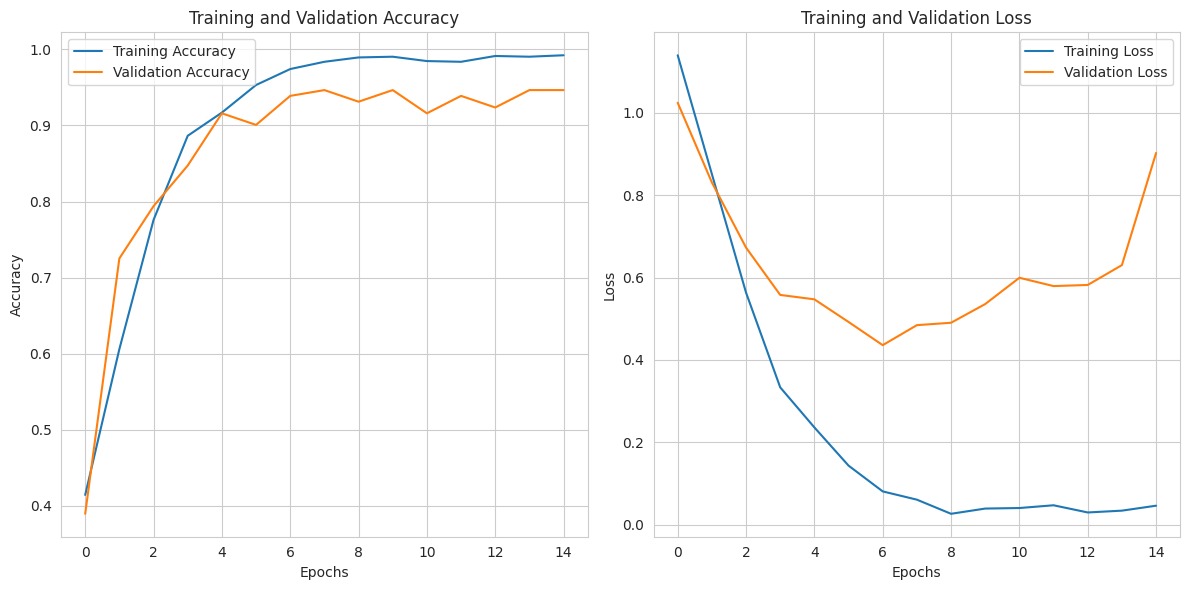

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


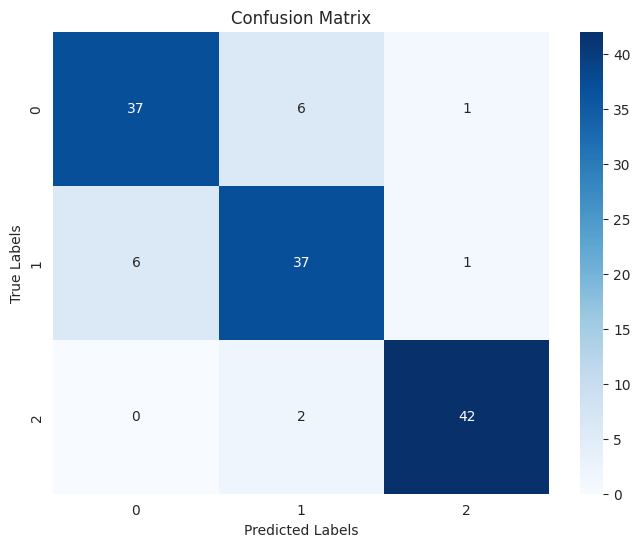

              precision    recall  f1-score   support

           0       0.86      0.84      0.85        44
           1       0.82      0.84      0.83        44
           2       0.95      0.95      0.95        44

    accuracy                           0.88       132
   macro avg       0.88      0.88      0.88       132
weighted avg       0.88      0.88      0.88       132



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

predictions = model.predict(test_gen_new, batch_size=batch_size)
predictions = np.argmax(predictions, axis=1)

true_labels = test_gen_new.classes

conf_matrix = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_gen_new.class_indices, yticklabels=test_gen_new.class_indices)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

class_report = classification_report(true_labels, predictions, target_names=test_gen_new.class_indices.keys())
print(class_report)

# CNN-Random Forest Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def create_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    return model

# Create CNN model for feature extraction
input_shape = (224, 224, 3)
cnn_model = create_cnn_model(input_shape)

# Convert generators to lists of images and labels
def convert_generator_to_rl_data(generator):
    images = []
    labels = []
    for _ in range(len(generator)):
        batch_images, batch_labels = next(generator)
        images.extend(batch_images)
        labels.extend(batch_labels)
    return np.array(images), np.array(labels)

train_images, train_labels = convert_generator_to_rl_data(train_gen_new)
test_images, test_labels = convert_generator_to_rl_data(test_gen_new)

# Extract features from training data
X_train_features = np.array([cnn_model.predict(img_to_array(img).reshape(1, 224, 224, 3)) for img in train_images])
X_train_features = X_train_features.reshape(len(train_images), -1)  # Flatten features

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_features, train_labels)

# Extract features from validation/test data
X_test_features = np.array([cnn_model.predict(img_to_array(img).reshape(1, 224, 224, 3)) for img in test_images])
X_test_features = X_test_features.reshape(len(test_images), -1)

# Predict using Random Forest
y_pred = rf_model.predict(X_test_features)
y_prob = rf_model.predict_proba(X_test_features)[:, 1]  # Probabilities for AUC-ROC

# Classification Report
print("Classification Report:\n", classification_report(test_labels, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/

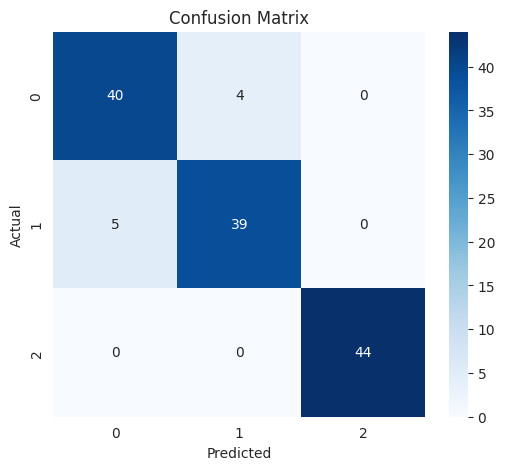

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━

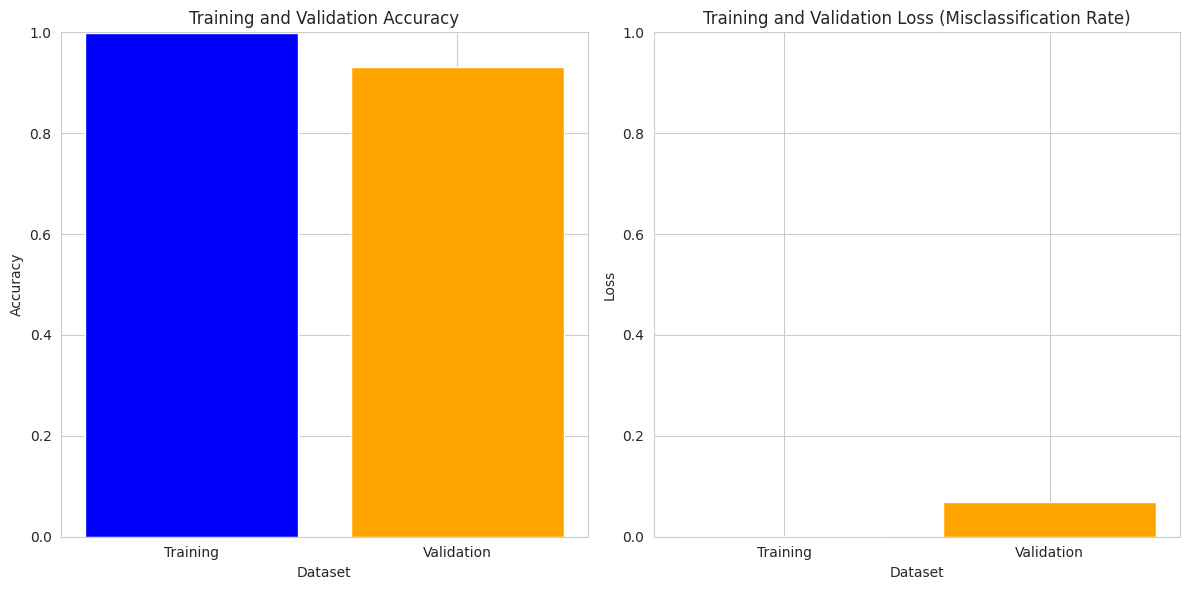

In [ ]:
# Training and Validation Accuracy & Loss Plots
# Regenerate X_train_features with the cnn_model
X_train_features = np.array([cnn_model.predict(img_to_array(img).reshape(1, 224, 224, 3)) for img in train_images])
X_train_features = X_train_features.reshape(len(train_images), -1)  # Flatten features

# Regenerate X_test_features with the cnn_model
X_test_features = np.array([cnn_model.predict(img_to_array(img).reshape(1, 224, 224, 3)) for img in test_images])
X_test_features = X_test_features.reshape(len(test_images), -1)

train_accuracy = rf_model.score(X_train_features, train_labels)  # RF accuracy on training data
test_accuracy = rf_model.score(X_test_features, test_labels)  # RF accuracy on test data

train_loss = 1 - train_accuracy  # Misclassification rate for training
test_loss = 1 - test_accuracy  # Misclassification rate for test

plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.bar(["Training", "Validation"], [train_accuracy, test_accuracy], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.title("Training and Validation Accuracy")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")

# Loss Plot
plt.subplot(1, 2, 2)
plt.bar(["Training", "Validation"], [train_loss, test_loss], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.title("Training and Validation Loss (Misclassification Rate)")
plt.xlabel("Dataset")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

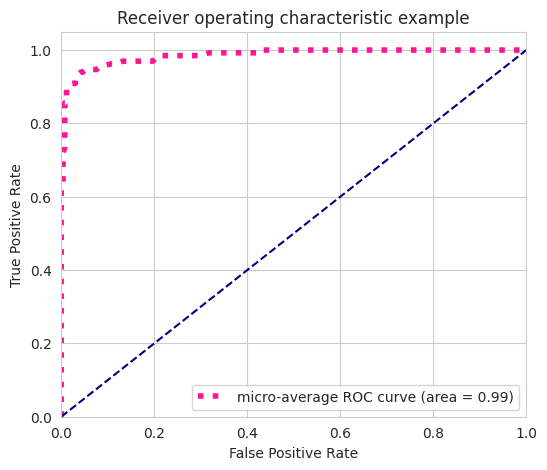

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the true labels (one-vs-rest approach)
y_true_bin = label_binarize(test_labels, classes=np.unique(test_labels))

# Predict using Random Forest (get probabilities for all classes)
y_pred = rf_model.predict(X_test_features)
y_prob = rf_model.predict_proba(X_test_features)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_true_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves for each class or micro-average
plt.figure(figsize=(6, 5))
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

# CNN-XGB Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/s

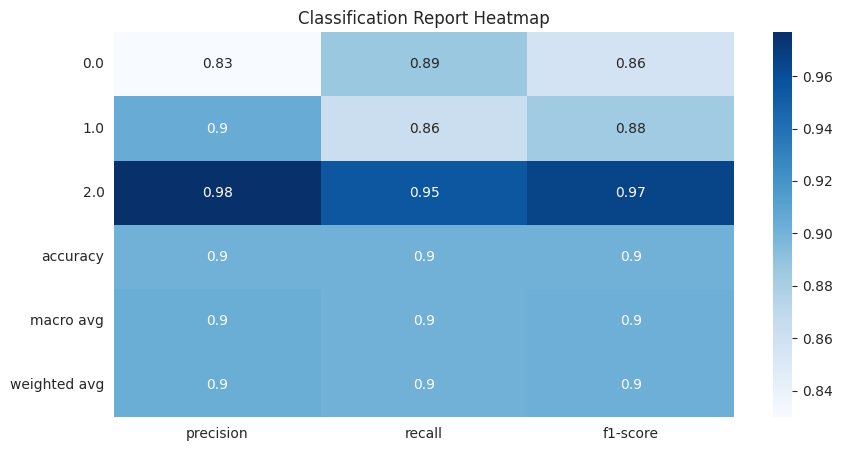

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def create_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    return model

# Create CNN model for feature extraction
input_shape = (224, 224, 3)
cnn_model = create_cnn_model(input_shape)

def convert_generator_to_rl_data(generator):
    images, labels = [], []
    for _ in range(len(generator)):
        batch_images, batch_labels = next(generator)
        images.extend(batch_images)
        labels.extend(batch_labels)
    return np.array(images), np.array(labels)

train_images, train_labels = convert_generator_to_rl_data(train_gen_new)
test_images, test_labels = convert_generator_to_rl_data(test_gen_new)

# Extract features from training data
X_train_features = np.array([cnn_model.predict(img_to_array(img).reshape(1, 224, 224, 3)) for img in train_images])
X_train_features = X_train_features.reshape(len(train_images), -1)

# Train XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_features, train_labels)

# Extract features from validation/test data
X_test_features = np.array([cnn_model.predict(img_to_array(img).reshape(1, 224, 224, 3)) for img in test_images])
X_test_features = X_test_features.reshape(len(test_images), -1)

# Predict using XGBoost
y_pred = xgb_model.predict(X_test_features)

# Classification Report
report = classification_report(test_labels, y_pred, output_dict=True)
print("Classification Report:\n", classification_report(test_labels, y_pred))

# Function to plot classification report
def plot_classification_report(report):
    plt.figure(figsize=(10, 5))
    sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap='Blues')
    plt.title('Classification Report Heatmap')
    plt.show()

# Plot classification report
plot_classification_report(report)


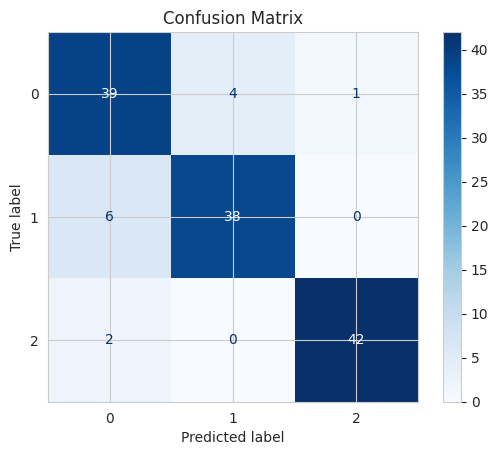

In [ ]:
# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()
    return cm

# Plot confusion matrix
cm = plot_confusion_matrix(test_labels, y_pred)

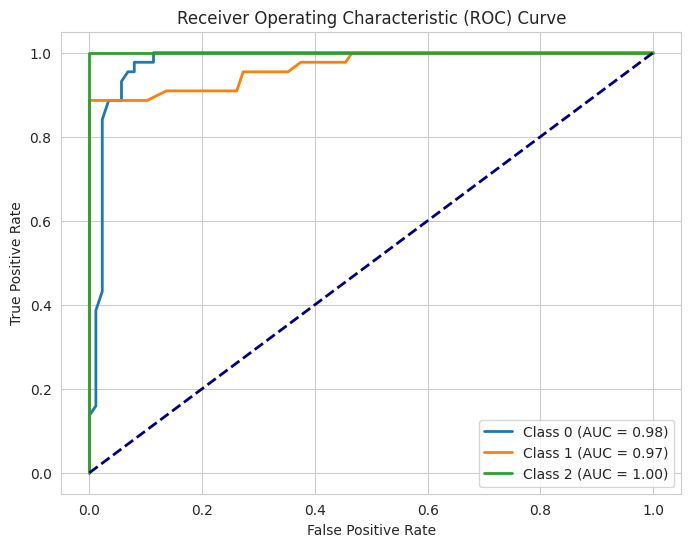

In [ ]:
# Function to plot AUC-ROC curve for multi-class classification
def plot_auc_roc(y_true, y_prob, n_classes):
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true == i, y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()
    return fpr, tpr, roc_auc

# Plot AUC-ROC curve
fpr, tpr, roc_auc = plot_auc_roc(test_labels, y_prob, n_classes)


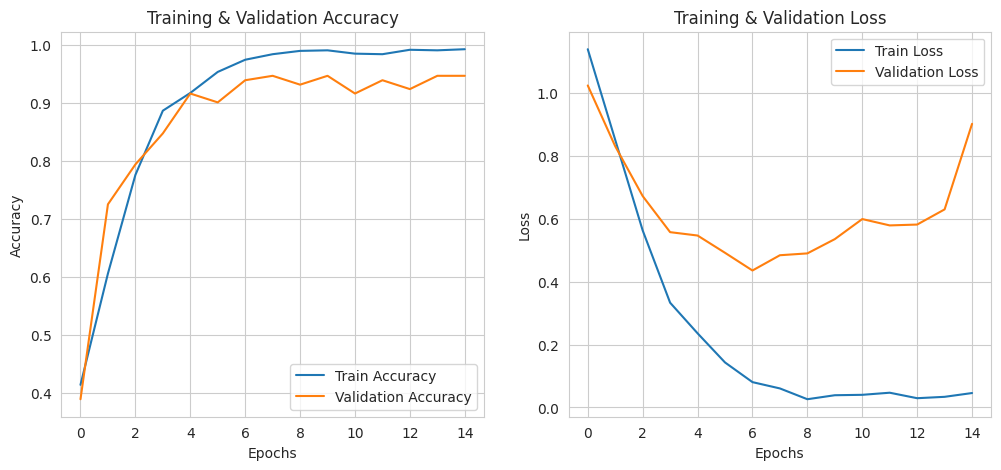

In [ ]:
# Plot training and validation accuracy & loss
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()

    plt.show()

# Call the function to plot training history
plot_training_history(history)

# CNN-Transformer Model

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 472s 14s/step - accuracy: 0.3245 - loss: 1.4712 - val_accuracy: 0.3333 - val_loss: 1.1191
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 435s 13s/step - accuracy: 0.3286 - loss: 1.1229 - val_accuracy: 0.3333 - val_loss: 1.1006
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 434s 13s/step - accuracy: 0.3396 - loss: 1.1245 - val_accuracy: 0.3333 - val_loss: 1.1157
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 426s 12s/step - accuracy: 0.3434 - loss: 1.1035 - val_accuracy: 0.3333 - val_loss: 1.0995
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 465s 13s/step - accuracy: 0.3385 - loss: 1.1044 - val_accuracy: 0.3333 - val_loss: 1.1006
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 431s 13s/step - accuracy: 0.3318 - loss: 1.1081 - val_accuracy: 0.3333 - val_loss: 1.0985
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 445s 13s/step - accuracy: 0.3411 - loss: 1.0993 - val_accuracy: 0.3333 - val_loss: 1.0980
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 448s 13s/step - accuracy: 0.3020 - loss: 1.1035 - val_accuracy: 0.

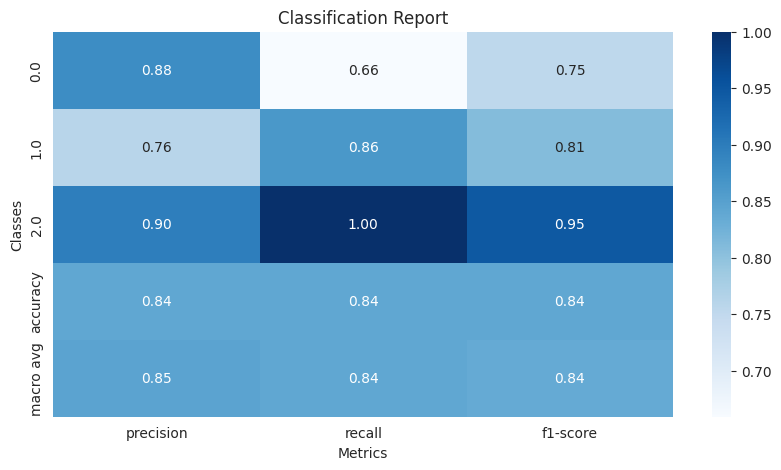

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, LayerNormalization, MultiHeadAttention, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def transformer_block(inputs, num_heads=8, key_dim=64):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(inputs, inputs)
    attn_output = LayerNormalization(epsilon=1e-6)(attn_output + inputs)
    return attn_output

def create_cnn_transformer_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # CNN Feature Extraction
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Transformer Encoder
    x = transformer_block(x)
    x = GlobalAveragePooling2D()(x)

    # Fully Connected Layers
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create CNN-Transformer model
input_shape = (224, 224, 3)
num_classes = len(np.unique(train_labels))
cnn_transformer_model = create_cnn_transformer_model(input_shape, num_classes)

# Train model
history = cnn_transformer_model.fit(
    train_images,
    tf.keras.utils.to_categorical(train_labels, num_classes=num_classes),  # Convert to one-hot encoding
    validation_data=(test_images, tf.keras.utils.to_categorical(test_labels, num_classes=num_classes)),  # Convert to one-hot encoding
    epochs=15,
    batch_size=32
)

# Feature Extraction
X_train_features = cnn_transformer_model.predict(train_images)
X_train_features = X_train_features.reshape(len(train_images), -1)

# Train XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_features, train_labels)

# Extract features from validation/test data
X_test_features = cnn_transformer_model.predict(test_images)
X_test_features = X_test_features.reshape(len(test_images), -1)

# Predict using XGBoost
y_pred = xgb_model.predict(X_test_features)

# Classification Report
report = classification_report(test_labels, y_pred, output_dict=True)
print("Classification Report:\n", classification_report(test_labels, y_pred))

def plot_classification_report(y_true, y_pred, class_names):
    report = classification_report(y_true, y_pred, output_dict=True)
    df = pd.DataFrame(report).transpose()
    plt.figure(figsize=(10, 5))
    sns.heatmap(df.iloc[:-1, :-1], annot=True, cmap='Blues', fmt='.2f')
    plt.title('Classification Report')
    plt.xlabel('Metrics')
    plt.ylabel('Classes')
    plt.show()

# Plot classification report
plot_classification_report(test_labels, y_pred, class_names=np.unique(test_labels))


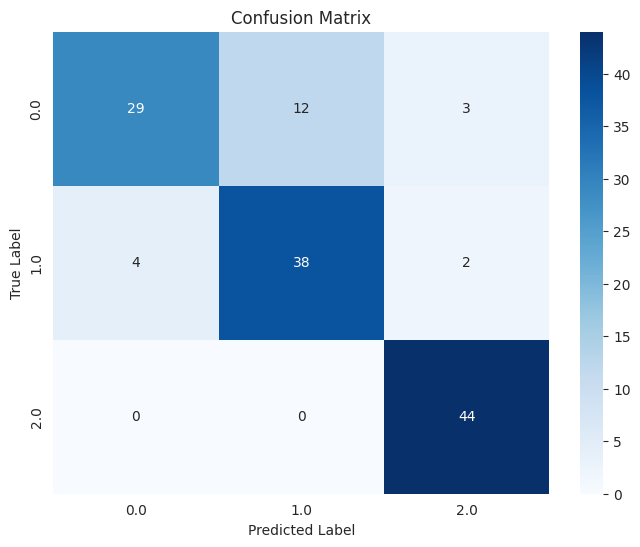

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Plot confusion matrix
plot_confusion_matrix(test_labels, y_pred, class_names=np.unique(test_labels))


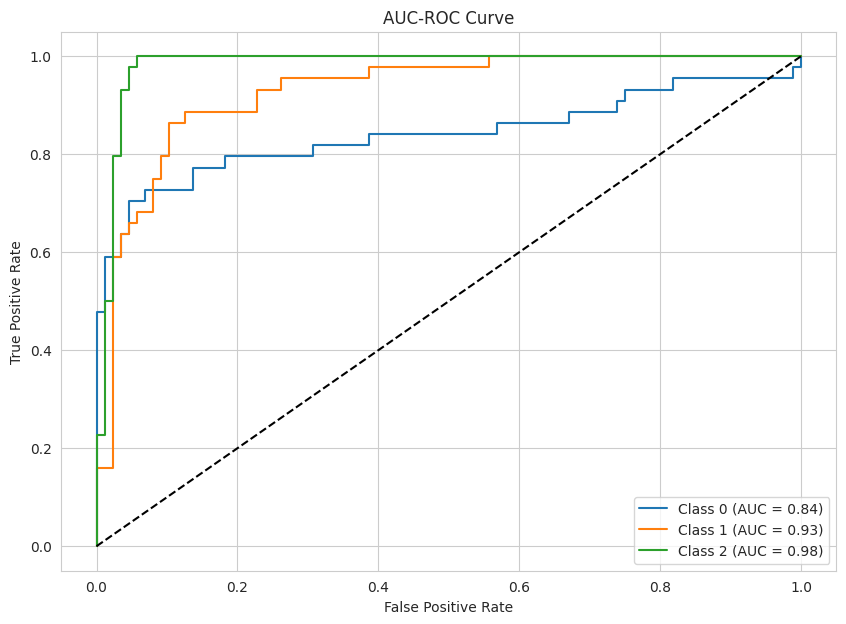

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class ROC AUC computation
num_classes = len(np.unique(test_labels))
y_true_bin = label_binarize(test_labels, classes=np.unique(test_labels))
y_pred_prob = xgb_model.predict_proba(X_test_features)  # Get probability scores for each class

# Plot ROC curve for each class
plt.figure(figsize=(10, 7))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal reference line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve')
plt.legend(loc='lower right')
plt.show()


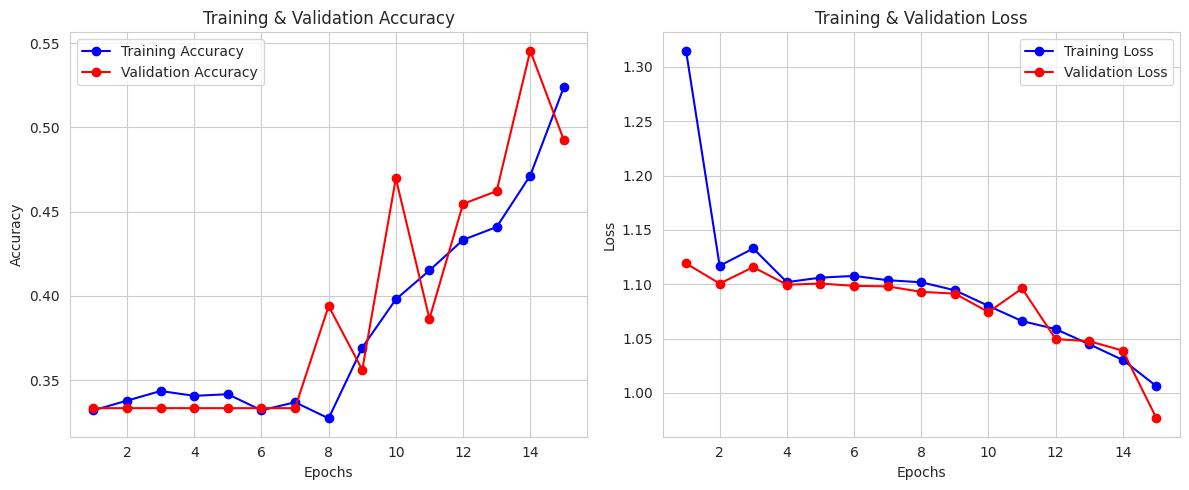

In [ ]:
# Plot Training & Validation Accuracy and Loss
def plot_training_history(history):
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Plot Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], 'bo-', label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], 'ro-', label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], 'bo-', label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], 'ro-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call function to plot
plot_training_history(history)


# Inception V3 Model

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 588s 8s/step - accuracy: 0.6256 - loss: 1.0126 - val_accuracy: 0.3282 - val_loss: 119.8330
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 558s 8s/step - accuracy: 0.7845 - loss: 0.6566 - val_accuracy: 0.3359 - val_loss: 4.7187
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 517s 8s/step - accuracy: 0.7940 - loss: 0.5589 - val_accuracy: 0.6260 - val_loss: 1.1663
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 511s 8s/step - accuracy: 0.8743 - loss: 0.3950 - val_accuracy: 0.7557 - val_loss: 1.0014
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 514s 8s/step - accuracy: 0.9287 - loss: 0.2395 - val_accuracy: 0.7939 - val_loss: 0.6885
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 519s 8s/step - accuracy: 0.9457 - loss: 0.1956 - val_accuracy: 0.6641 - val_loss: 1.2606
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 514s 8s/step - accuracy: 0.9165 - loss: 0.2685 - val_accuracy: 0.6336 - val_loss: 2.1538
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 522s 8s/step - accur

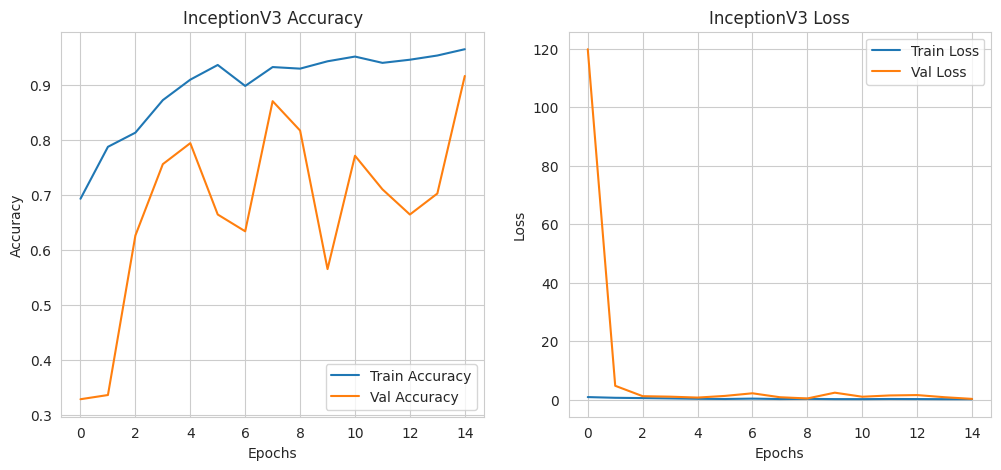

9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.89      0.92        44
           1       0.93      0.93      0.93        44
           2       0.94      1.00      0.97        44

    accuracy                           0.94       132
   macro avg       0.94      0.94      0.94       132
weighted avg       0.94      0.94      0.94       132



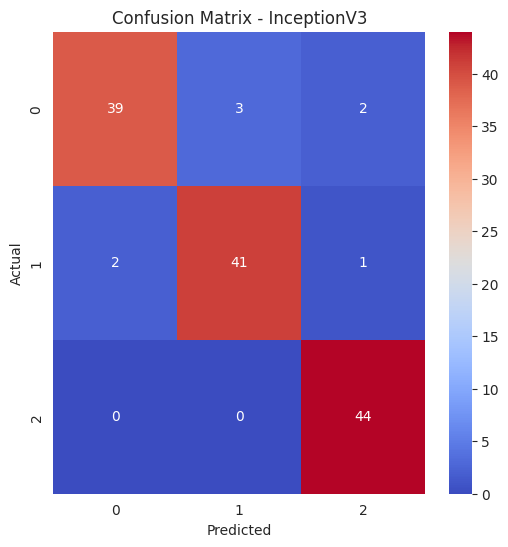

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Function to create InceptionV3 model
def create_inception_model(input_shape, num_classes):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Initialize the model
input_shape = (224, 224, 3)  # Adjust based on your dataset
num_classes = len(train_df_new['category_encoded'].unique())  # Number of unique labels
inception_model = create_inception_model(input_shape, num_classes)

# Train the model
num_epochs = 10
history = inception_model.fit(train_gen_new, validation_data=valid_gen_new, epochs=15)

# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("InceptionV3 Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("InceptionV3 Loss")
plt.legend()

plt.show()

# Assuming test_gen_new is your test data generator
# Get true labels and predictions
y_true = test_gen_new.classes  # Get true labels from the generator
y_pred_probs = inception_model.predict(test_gen_new)  # Predict using the generator
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix with Colors
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - InceptionV3")
plt.show()

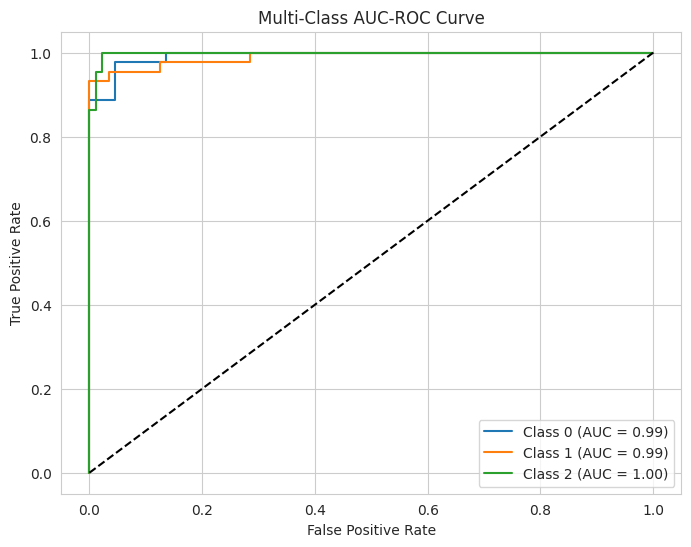

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for multi-class ROC computation
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot the diagonal reference line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class AUC-ROC Curve')
plt.legend(loc="lower right")
plt.show()


# VGG16 Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Function to create VGG16 model
def create_vgg16_model(input_shape, num_classes):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Initialize the model
input_shape = (224, 224, 3)  # Adjust based on your dataset
num_classes = len(train_df_new['category_encoded'].unique())  # Number of unique labels
vgg16_model = create_vgg16_model(input_shape, num_classes)

# Train the model
num_epochs = 15
history = vgg16_model.fit(train_gen_new, validation_data=valid_gen_new, epochs=num_epochs)

# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("VGG16 Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("VGG16 Loss")
plt.legend()

plt.show()

# Assuming test_gen_new is your test data generator
# Get true labels and predictions
y_true = test_gen_new.classes  # Get true labels from the generator
y_pred_probs = vgg16_model.predict(test_gen_new)  # Predict using the generator
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix with Colors
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG16")
plt.show()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2099s 32s/step - accuracy: 0.3236 - loss: 3.3564 - val_accuracy: 0.3511 - val_loss: 1.0993
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2126s 32s/step - accuracy: 0.3359 - loss: 1.1005 - val_accuracy: 0.3282 - val_loss: 1.0996
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2079s 32s/step - accuracy: 0.3045 - loss: 1.1067 - val_accuracy: 0.3359 - val_loss: 1.0986
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2139s 32s/step - accuracy: 0.3215 - loss: 1.0995 - val_accuracy: 0.3359 - val_loss: 1.0986
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2141s 32s/step - accuracy: 0.3389 - loss: 1.0986 - val_accuracy: 0.3359 - val_loss: 1.0986
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2126s 32s/step - accuracy: 0.3749 - loss: 1.0985 - val_accuracy: 0.3359 - val_loss: 1.0987
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2113s 32s/step - accuracy: 0.3375 - loss: 1.0994 - val_accuracy: 0.3359 - val_loss: 1.0986
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2116s 32